In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os

# Set global font to Times New Roman
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

# Load the raw data
df = pd.read_csv('../data/raw_data.csv')
print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (20, 2)


,text,sentiment
0,I absolutely loved this movie! The acting was ...,1
1,Worst experience ever. The service was terribl...,0
2,"The new update is amazing, everything works so...",1
3,I'm very disappointed with the quality of this...,0
4,Great food and even better atmosphere. Highly ...,1


C:\Users\Asus\AppData\Local\Temp\ipykernel_14208\4123429043.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='sentiment', data=df, palette='viridis')


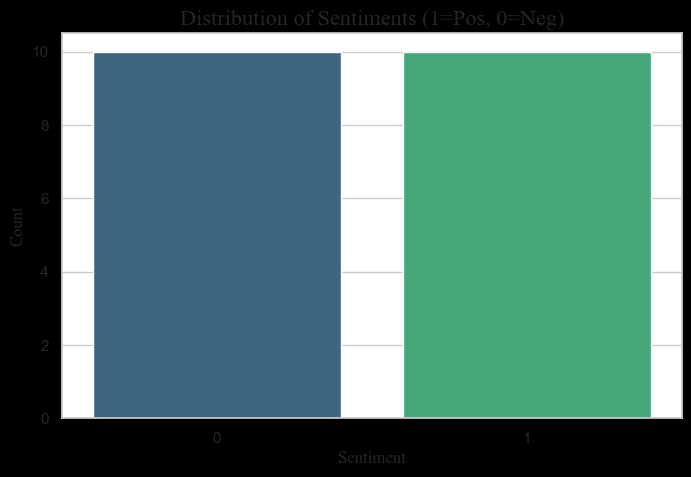

In [3]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid") # Optional: clean background

# Plotting with explicit font control
ax = sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiments (1=Pos, 0=Neg)', fontsize=16, fontfamily='serif')
plt.xlabel('Sentiment', fontsize=12, fontfamily='serif')
plt.ylabel('Count', fontsize=12, fontfamily='serif')

plt.show()

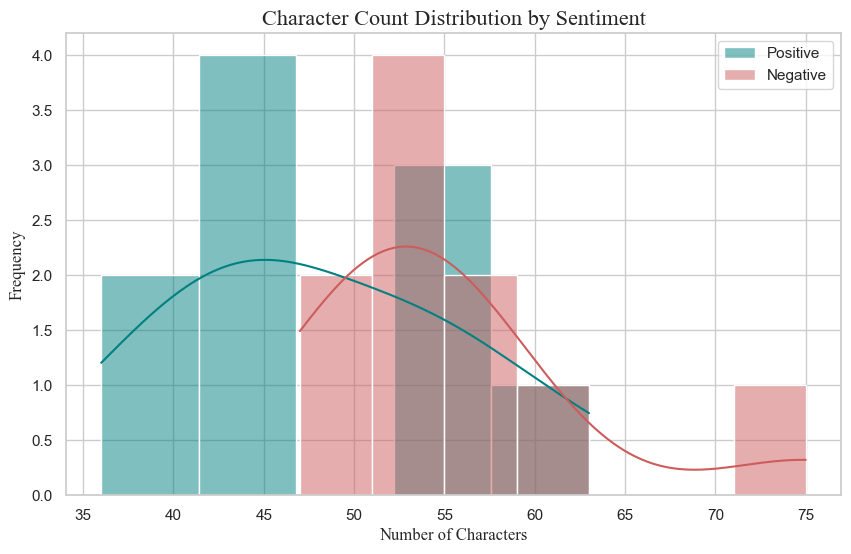

In [4]:
# Calculate character count for each review
df['char_count'] = df['text'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(df[df['sentiment']==1]['char_count'], label='Positive', color='teal', kde=True)
sns.histplot(df[df['sentiment']==0]['char_count'], label='Negative', color='indianred', kde=True)

plt.title('Character Count Distribution by Sentiment', fontsize=16, fontfamily='serif')
plt.xlabel('Number of Characters', fontsize=12, fontfamily='serif')
plt.ylabel('Frequency', fontsize=12, fontfamily='serif')
plt.legend()
plt.show()

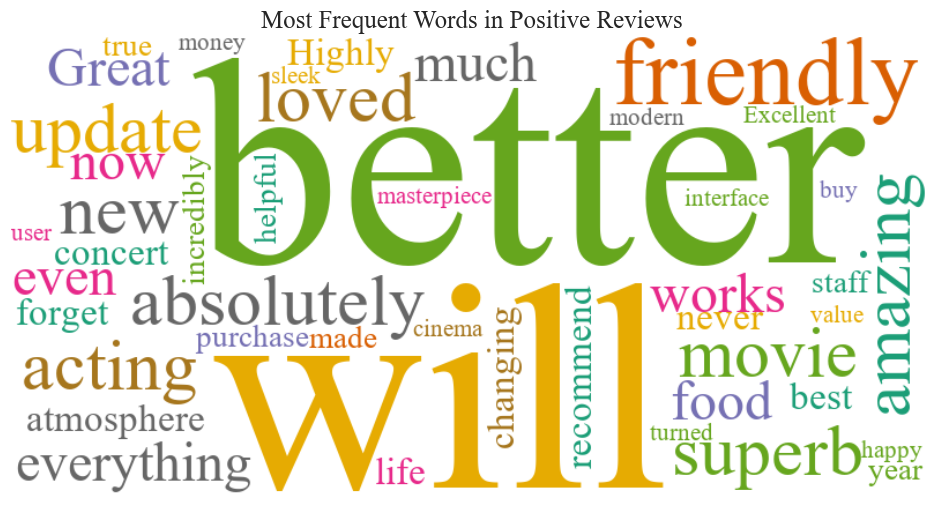

In [5]:
# Join all positive text
pos_text = " ".join(df[df['sentiment']==1]['text'])

# Path to Times New Roman (Windows path)
# Mac: '/Library/Fonts/Times New Roman.ttf'
font_path = 'C:/Windows/Fonts/times.ttf'

wordcloud = WordCloud(
    font_path=font_path,
    width=800,
    height=400,
    background_color='white',
    colormap='Dark2'
).generate(pos_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Positive Reviews', fontsize=18, fontfamily='serif')
plt.show()


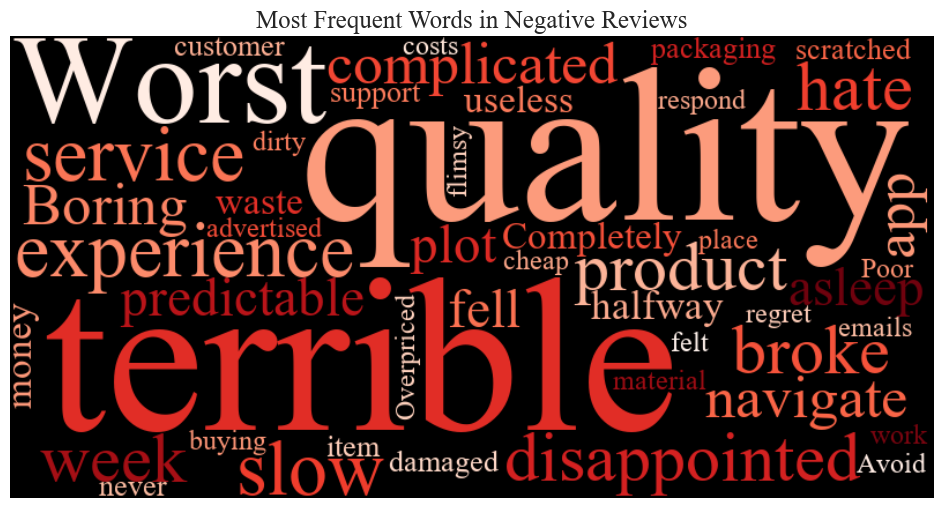

In [6]:
neg_text = " ".join(df[df['sentiment']==0]['text'])

wordcloud_neg = WordCloud(
    font_path=font_path,
    width=800,
    height=400,
    background_color='black',
    colormap='Reds'
).generate(neg_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Negative Reviews', fontsize=18, fontfamily='serif')
plt.show()